Current best result: 0.80476 (with XGBoost). Support Vector Classifier achieves 0.80102 accuracy.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


Let's read the data and look at it

In [2]:
train_data = pd.read_csv("/kaggle/input/spaceship-titanic/train.csv", index_col = 'PassengerId')
train_data.sample(20)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
PassengerId,,,,,,,,,,,,,
5198_01,Mars,False,F/1059/P,TRAPPIST-1e,45.0,False,878.0,0.0,430.0,0.0,0.0,Lish Fla,False
3283_04,Earth,False,G/521/S,TRAPPIST-1e,38.0,False,0.0,0.0,0.0,846.0,0.0,Brank Hoopez,False
9168_01,Europa,False,C/338/S,55 Cancri e,36.0,False,23.0,14773.0,0.0,1159.0,7819.0,Hadirk Cassiding,False
8115_01,Europa,True,B/318/S,TRAPPIST-1e,31.0,False,0.0,0.0,0.0,0.0,0.0,Phecca Prieress,True
7609_01,Europa,False,A/83/P,55 Cancri e,40.0,True,0.0,21.0,0.0,1503.0,1392.0,Astorux Reeddommy,False
4569_02,Europa,NaN,B/151/P,55 Cancri e,37.0,False,0.0,2235.0,7.0,4098.0,89.0,Aldah Honchoe,False
1414_01,Earth,False,F/280/P,TRAPPIST-1e,65.0,False,259.0,0.0,0.0,0.0,1916.0,Andace Kinson,False
2723_02,Europa,False,C/99/S,TRAPPIST-1e,54.0,False,0.0,5876.0,0.0,0.0,914.0,Dabiton Boderbint,True
7052_01,Europa,NaN,E/469/S,55 Cancri e,27.0,False,0.0,0.0,0.0,0.0,0.0,Terons Stranbeate,True


In [3]:
test_data = pd.read_csv("/kaggle/input/spaceship-titanic/test.csv", index_col = 'PassengerId')
test_data.sample(20)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
PassengerId,,,,,,,,,,,,
9067_01,Earth,False,G/1459/S,TRAPPIST-1e,14.0,False,11.0,292.0,713.0,777.0,0.0,Janney Baxters
9090_01,Earth,False,G/1464/S,TRAPPIST-1e,19.0,False,308.0,0.0,251.0,1099.0,NaN,Mollie Morez
1111_03,Earth,False,E/77/S,55 Cancri e,25.0,False,0.0,0.0,150.0,562.0,6.0,Alie Burnerez
4789_01,Mars,True,E/298/P,TRAPPIST-1e,15.0,False,0.0,0.0,0.0,0.0,0.0,Allota Sad
4675_02,Europa,False,C/149/P,TRAPPIST-1e,26.0,False,0.0,439.0,4460.0,2525.0,11225.0,Izares Coarswing
4582_05,Earth,True,G/748/S,TRAPPIST-1e,16.0,False,0.0,0.0,0.0,0.0,0.0,Bonne Barris
5513_02,Earth,True,G/888/S,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,0.0,0.0,Min Mayods
8308_01,Earth,False,F/1708/P,PSO J318.5-22,45.0,False,0.0,0.0,9.0,2536.0,4.0,Kaye Hanner
6686_01,Europa,False,C/211/P,TRAPPIST-1e,31.0,False,NaN,3866.0,0.0,381.0,2168.0,Marfak Objeciane


# EDA

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [5]:
train_data.columns

Index(['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP',
       'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name',
       'Transported'],
      dtype='object')

In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 0001_01 to 9280_02
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   object 
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   object 
 3   Destination   8511 non-null   object 
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Name          8493 non-null   object 
 12  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(6)
memory usage: 891.4+ KB


In [7]:
train_data.isna().sum()/train_data.shape[0]

HomePlanet      0.023122
CryoSleep       0.024963
Cabin           0.022892
Destination     0.020936
Age             0.020591
VIP             0.023352
RoomService     0.020821
FoodCourt       0.021051
ShoppingMall    0.023927
Spa             0.021051
VRDeck          0.021627
Name            0.023007
Transported     0.000000
dtype: float64

<AxesSubplot:ylabel='PassengerId'>

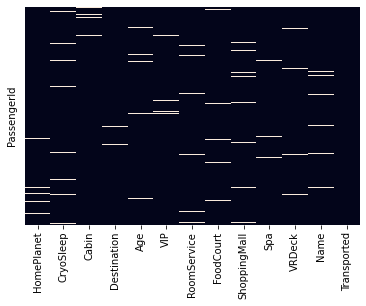

In [8]:
sns.heatmap(train_data.isnull(),yticklabels=False,cbar=False)

All columns, except for the target one (Transported), have missing values

In [9]:
train_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [10]:
train_data.HomePlanet.value_counts()

Earth     4602
Europa    2131
Mars      1759
Name: HomePlanet, dtype: int64

<AxesSubplot:xlabel='HomePlanet', ylabel='count'>

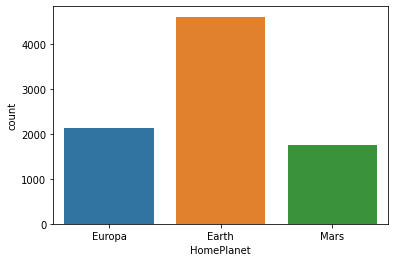

In [11]:
sns.countplot(x='HomePlanet', data=train_data)

In [12]:
train_data.Destination.value_counts()

TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: Destination, dtype: int64

<AxesSubplot:xlabel='Destination', ylabel='count'>

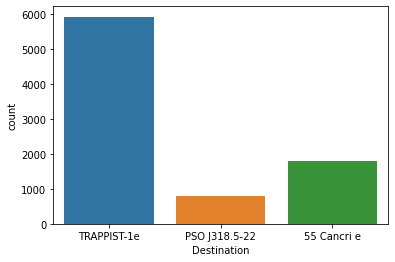

In [13]:
sns.countplot(x='Destination', data=train_data)

In [14]:
train_data.CryoSleep.value_counts()

False    5439
True     3037
Name: CryoSleep, dtype: int64

<AxesSubplot:xlabel='CryoSleep', ylabel='count'>

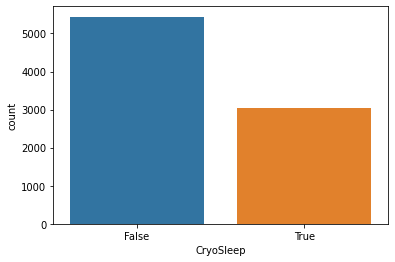

In [15]:
sns.countplot(x='CryoSleep', data=train_data)

In [16]:
train_data.Transported.value_counts()

True     4378
False    4315
Name: Transported, dtype: int64

<AxesSubplot:xlabel='Transported', ylabel='count'>

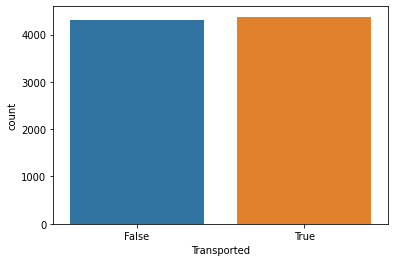

In [17]:
sns.countplot(x='Transported', data=train_data)

<AxesSubplot:>

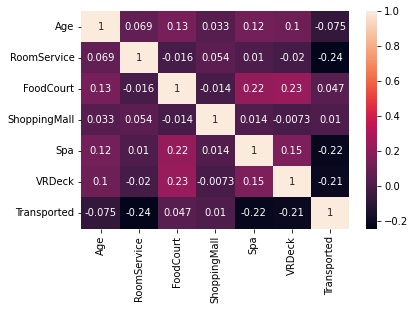

In [18]:
sns.heatmap(train_data.corr(method ='pearson'), annot=True)

In [19]:
train_data.groupby(['Transported', 'HomePlanet']).agg({'Transported': 'count'})

Transported
Transported HomePlanet             
False       Earth              2651
            Europa              727
            Mars                839
True        Earth              1951
            Europa             1404
            Mars                920

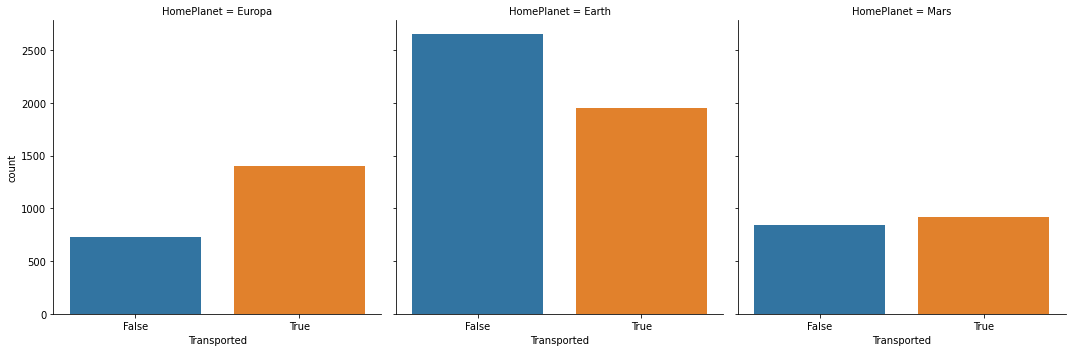

In [20]:
sns.catplot(x='Transported',col='HomePlanet',kind='count',data=train_data)

In [21]:
train_data.groupby(['Transported', 'Destination']).agg({'Transported': 'count'})

Transported
Transported Destination               
False       55 Cancri e            702
            PSO J318.5-22          395
            TRAPPIST-1e           3128
True        55 Cancri e           1098
            PSO J318.5-22          401
            TRAPPIST-1e           2787

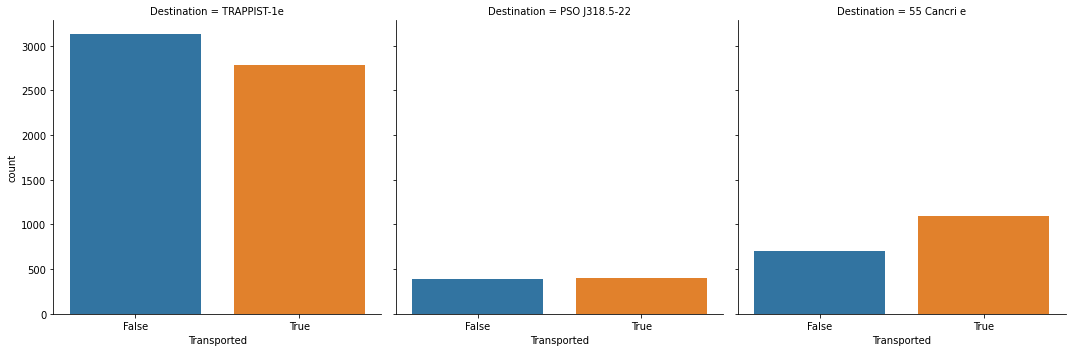

In [22]:
sns.catplot(x='Transported',col='Destination',kind='count',data=train_data)

In [23]:
train_data.groupby(['Transported', 'CryoSleep']).agg({'Transported': 'count'})

Transported
Transported CryoSleep             
False       False             3650
            True               554
True        False             1789
            True              2483

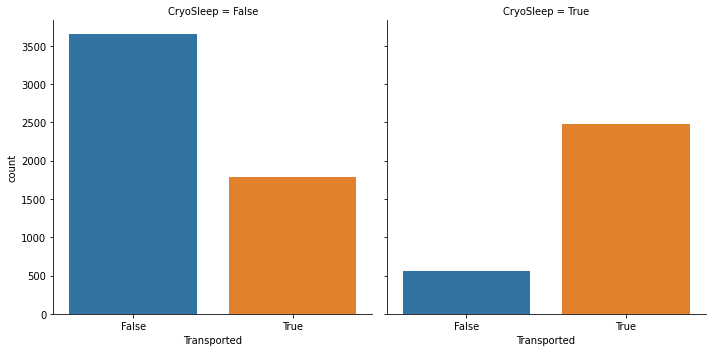

In [24]:
sns.catplot(x='Transported',col='CryoSleep',kind='count',data=train_data)

It seems that your chances of being transported are somewhat increased by European origin and heavily increased by being in criosleep...

# Preprocessing

In [25]:
y_train = train_data.Transported
X_train_full = train_data.drop(['Transported'], axis=1, inplace=False)
X_test_full = test_data

In [26]:
X_train_full

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
PassengerId,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines
...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther
9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley
9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon


In [27]:
X_train_full.isna().sum()

HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64

In [28]:
X_test_full.isna().sum()

HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [29]:
list(X_train_full['Name'][:200])

['Maham Ofracculy',
 'Juanna Vines',
 'Altark Susent',
 'Solam Susent',
 'Willy Santantines',
 'Sandie Hinetthews',
 'Billex Jacostaffey',
 'Candra Jacostaffey',
 'Andona Beston',
 'Erraiam Flatic',
 'Altardr Flatic',
 'Wezena Flatic',
 'Berers Barne',
 'Reney Baketton',
 'Elle Bertsontry',
 'Justie Pooles',
 'Flats Eccle',
 'Carry Hughriend',
 'Alus Upead',
 'Lyde Brighttt',
 'Philda Brighttt',
 'Almary Brantuarez',
 'Glendy Brantuarez',
 'Mollen Mcfaddennon',
 'Breney Jacostanley',
 'Mael Brantuarez',
 'Terta Mcfaddennon',
 nan,
 'Penton Fullided',
 'Karard Brookenson',
 'Anyoni Unconary',
 'Ceros Mare',
 'Ginia Morsentley',
 'Coobix Datie',
 'Cinets Datie',
 'Dontch Datie',
 'Ziba Oingwhedly',
 'Luse Butte',
 'Marina Leodger',
 'Loise Wheelez',
 'Jorgie Batthewitt',
 'Margia Moodsey',
 'Ankalik Cylistrand',
 'Jodye Coopelandez',
 'Kayne Coopelandez',
 'Cassa Coopelandez',
 'Zelowl Chmad',
 'Mass Chmad',
 'Sony Lancis',
 'Vivia Johnshines',
 'Elaney Hubbarton',
 'Elson Hickerson',
 '

Idea: Does any name consists of (one-word) first name and (one-word) last name? Perhaps we can split them and count family size (supposing that members of the same family share last name)?

In [30]:
X_train_full[['FirstName', 'LastName']] = X_train_full['Name'].str.split(' ', expand=True, n=1)
X_train_full.drop(columns=['Name'], inplace=True)
X_train_full

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,FirstName,LastName
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham,Ofracculy
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna,Vines
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark,Susent
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam,Susent
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy,Santantines
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior,Noxnuther
9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta,Mondalley
9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey,Connon


In [31]:
X_train_full['LastName'].nunique()

2217

In [32]:
X_train_full['LastName'].isna().sum()

200

In [33]:
X_train_full['FirstName'].fillna(value='Unknown',inplace=True)
X_train_full['LastName'].fillna(value='Unknown',inplace=True)

In [34]:
X_test_full[['FirstName', 'LastName']] = X_test_full['Name'].str.split(' ', expand=True, n=1)
X_test_full.drop(columns=['Name'], inplace=True)
X_test_full

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,FirstName,LastName
PassengerId,,,,,,,,,,,,,
0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly,Carsoning
0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome,Peckers
0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih,Unhearfus
0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz,Caltilter
0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence,Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron,Peter
9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty,Scheron
9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin,Pore


In [35]:
X_test_full['FirstName'].fillna(value='Unknown',inplace=True)
X_test_full['LastName'].fillna(value='Unknown',inplace=True)

In [36]:
X_test_full['LastName'].nunique()

1726

In [37]:
len(set(X_train_full['LastName']).intersection(set(X_test_full['LastName'])))

1537

It seems that members of the same family are VERY often present in both train and test set, so let's count family size using all the data

In [38]:
X_all = pd.concat([X_train_full, X_test_full])
X_all

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,FirstName,LastName
PassengerId,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham,Ofracculy
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna,Vines
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark,Susent
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam,Susent
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy,Santantines
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron,Peter
9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty,Scheron
9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin,Pore


In [39]:
family_size = X_all['LastName'].value_counts()
family_size

Unknown       294
Belley         19
Buckentry      19
Casonston      18
Hinglendez     18
             ... 
Cabraseed       1
Miste           1
Imotive         1
Gepie           1
Replic          1
Name: LastName, Length: 2407, dtype: int64

In [40]:
import statistics
family_size['Unknown'] = statistics.median(family_size.values)
family_size['Unknown']

5

In [41]:
X_train_full['FamilySize'] = X_train_full['LastName'].apply(lambda s: family_size[s])
X_train_full

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,FirstName,LastName,FamilySize
PassengerId,,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham,Ofracculy,3
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna,Vines,4
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark,Susent,7
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam,Susent,7
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy,Santantines,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior,Noxnuther,3
9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta,Mondalley,5
9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey,Connon,8


In [42]:
X_test_full['FamilySize'] = X_test_full['LastName'].apply(lambda s: family_size[s])
X_test_full

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,FirstName,LastName,FamilySize
PassengerId,,,,,,,,,,,,,,
0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly,Carsoning,8
0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome,Peckers,4
0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih,Unhearfus,6
0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz,Caltilter,2
0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence,Harperez,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron,Peter,10
9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty,Scheron,6
9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin,Pore,4


In [43]:
X_train_full[['Deck', 'Num', 'Side']] = X_train_full['Cabin'].str.split('/', expand=True)
X_test_full[['Deck', 'Num', 'Side']] = X_test_full['Cabin'].str.split('/', expand=True)
X_train_full

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,FirstName,LastName,FamilySize,Deck,Num,Side
PassengerId,,,,,,,,,,,,,,,,,
0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham,Ofracculy,3,B,0,P
0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna,Vines,4,F,0,S
0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark,Susent,7,A,0,S
0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam,Susent,7,A,0,S
0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy,Santantines,9,F,1,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior,Noxnuther,3,A,98,P
9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta,Mondalley,5,G,1499,S
9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey,Connon,8,G,1500,S


In [44]:
X_train = X_train_full.drop(columns=['FirstName', 'LastName', 'Cabin', 'Num'])
X_test = test_data.drop(columns=['FirstName', 'LastName', 'Cabin', 'Num'])

In [45]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype=='object']
cat_cols

['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

In [46]:
num_cols = [col for col in X_train.columns if X_train[col].dtype=='float64']
num_cols

['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [47]:
luxury_cols = [col for col in num_cols if col != 'Age']
luxury_cols

['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [48]:
for col in cat_cols:
    X_train[col].fillna(value=X_train[col].mode()[0],inplace=True)
    X_test[col].fillna(value=X_train[col].mode()[0],inplace=True)

In [49]:
X_train.isna().sum()

HomePlanet        0
CryoSleep         0
Destination       0
Age             179
VIP               0
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
FamilySize        0
Deck              0
Side              0
dtype: int64

In [50]:
for col in luxury_cols:
    print(X_train.loc[X_train.CryoSleep==True, col].max())

0.0
0.0
0.0
0.0
0.0


In [51]:
for col in luxury_cols:
    print(X_train.loc[X_train.CryoSleep==False, col].min(), X_train.loc[X_train.CryoSleep==False, col].median())

0.0 2.0
0.0 4.0
0.0 1.0
0.0 6.0
0.0 3.0


In [52]:
median_costs = X_train.loc[X_train.CryoSleep==False, luxury_cols].median()
median_costs

RoomService     2.0
FoodCourt       4.0
ShoppingMall    1.0
Spa             6.0
VRDeck          3.0
dtype: float64

In [53]:
for col in luxury_cols:
    X_train[col].fillna(X_train.groupby('CryoSleep')[col].transform('median'), inplace=True)
    X_test[col].fillna(X_test.groupby('CryoSleep')[col].transform('median'), inplace=True)

In [54]:
X_train.isna().sum()

HomePlanet        0
CryoSleep         0
Destination       0
Age             179
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
FamilySize        0
Deck              0
Side              0
dtype: int64

In [55]:
X_train.Age.fillna(value=X_train.Age.median(),inplace=True)
X_test.Age.fillna(value=X_train.Age.median(),inplace=True)

In [56]:
X_train.isna().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
FamilySize      0
Deck            0
Side            0
dtype: int64

In [57]:
X_test.isna().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
FamilySize      0
Deck            0
Side            0
dtype: int64

In [58]:
# X_train['LuxurySpends'] = sum([X_train[col] for col in luxury_cols])
# X_test['LuxurySpends'] = sum([X_test[col] for col in luxury_cols])
# X_train.drop(columns=luxury_cols, inplace=True)
# X_test.drop(columns=luxury_cols, inplace=True)
# X_train

In [59]:
from sklearn.feature_selection import mutual_info_classif

# functions from the course on Feature Engineering, with modification (categorical target)
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")



In [60]:
make_mi_scores(X_train, y_train)

CryoSleep       0.113672
Spa             0.079762
RoomService     0.076679
VRDeck          0.065167
ShoppingMall    0.051071
FoodCourt       0.048732
Deck            0.022989
HomePlanet      0.018581
Age             0.011197
Destination     0.006113
Side            0.005149
FamilySize      0.002886
VIP             0.000692
Name: MI Scores, dtype: float64

In [61]:
X_train = pd.get_dummies(X_train)
X_train

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,FamilySize,HomePlanet_Earth,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
PassengerId,,,,,,,,,,,,,,,,,,,,,
0001_01,False,39.0,False,0.0,0.0,0.0,0.0,0.0,3,0,...,0,1,0,0,0,0,0,0,1,0
0002_01,False,24.0,False,109.0,9.0,25.0,549.0,44.0,4,1,...,0,0,0,0,0,1,0,0,0,1
0003_01,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,7,0,...,1,0,0,0,0,0,0,0,0,1
0003_02,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,7,0,...,1,0,0,0,0,0,0,0,0,1
0004_01,False,16.0,False,303.0,70.0,151.0,565.0,2.0,9,1,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9276_01,False,41.0,True,0.0,6819.0,0.0,1643.0,74.0,3,0,...,1,0,0,0,0,0,0,0,1,0
9278_01,True,18.0,False,0.0,0.0,0.0,0.0,0.0,5,1,...,0,0,0,0,0,0,1,0,0,1
9279_01,False,26.0,False,0.0,0.0,1872.0,1.0,0.0,8,1,...,0,0,0,0,0,0,1,0,0,1


In [62]:
X_test = pd.get_dummies(X_test)
X_test

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,FamilySize,HomePlanet_Earth,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
PassengerId,,,,,,,,,,,,,,,,,,,,,
0013_01,True,27.0,False,0.0,0.0,0.0,0.0,0.0,8,1,...,0,0,0,0,0,0,1,0,0,1
0018_01,False,19.0,False,0.0,9.0,0.0,2823.0,0.0,4,1,...,0,0,0,0,0,1,0,0,0,1
0019_01,True,31.0,False,0.0,0.0,0.0,0.0,0.0,6,0,...,0,0,1,0,0,0,0,0,0,1
0021_01,False,38.0,False,0.0,6652.0,0.0,181.0,585.0,2,0,...,0,0,1,0,0,0,0,0,0,1
0023_01,False,20.0,False,10.0,0.0,635.0,0.0,0.0,5,1,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9266_02,True,34.0,False,0.0,0.0,0.0,0.0,0.0,10,1,...,0,0,0,0,0,0,1,0,0,1
9269_01,False,42.0,False,0.0,847.0,17.0,10.0,144.0,6,1,...,0,0,0,0,0,1,0,0,0,1
9271_01,True,27.0,False,0.0,0.0,0.0,0.0,0.0,4,0,...,0,0,0,1,0,0,0,0,1,0


# Random Forest

In [63]:
from sklearn.model_selection import KFold, cross_val_score

from sklearn.ensemble import RandomForestClassifier

best_parameters = 0, 0
best_score = 0

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for k in range(100, 500, 100):
    for d in range(5, 20, 5):
        print(f'Number of trees = {k}, max depth = {d}')    
        clf = RandomForestClassifier(n_estimators=k, max_depth=d, random_state=42)
        score = round(cross_val_score(clf, X_train, y_train, cv = kf, scoring='accuracy').mean(), 3)
        print(f'Accuracy = {score}')
        if score > best_score:
            best_score = score
            best_parameters = k, d  
        

Number of trees = 100, max depth = 5
Accuracy = 0.775
Number of trees = 100, max depth = 10
Accuracy = 0.802
Number of trees = 100, max depth = 15
Accuracy = 0.795
Number of trees = 200, max depth = 5
Accuracy = 0.774
Number of trees = 200, max depth = 10
Accuracy = 0.801
Number of trees = 200, max depth = 15
Accuracy = 0.795
Number of trees = 300, max depth = 5
Accuracy = 0.772
Number of trees = 300, max depth = 10
Accuracy = 0.802
Number of trees = 300, max depth = 15
Accuracy = 0.794
Number of trees = 400, max depth = 5
Accuracy = 0.772
Number of trees = 400, max depth = 10
Accuracy = 0.801
Number of trees = 400, max depth = 15
Accuracy = 0.794


In [64]:
best_parameters

(100, 10)

In [65]:
model = RandomForestClassifier(n_estimators=best_parameters[0], max_depth=best_parameters[1], random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [66]:
output = pd.DataFrame({'PassengerId': X_test.index, 'Transported': predictions})
output.to_csv('submission_rf.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [67]:
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,True
4275,9273_01,True


# XGB 


In [68]:
from xgboost import XGBClassifier

best_score = 0
best_k = 0

for k in range(100, 1000, 100):
    print(f'{k} models')
    clf = XGBClassifier(n_estimators=k, learning_rate=0.05, n_jobs=4)
    clf.fit(X_train, y_train)
    score = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy').mean()
    print(f'{k}: Accuracy = {score}')
    if score > best_score:
        best_score = score
        best_k = k

100 models
100: Accuracy = 0.8039814953900599
200 models
200: Accuracy = 0.80191087691761
300 models
300: Accuracy = 0.7994950340493028
400 models
400: Accuracy = 0.8001848872842678
500 models
500: Accuracy = 0.8002994326991095
600 models
600: Accuracy = 0.8007592686827806
700 models
700: Accuracy = 0.7985735754117117
800 models
800: Accuracy = 0.7969626605769886
900 models
900: Accuracy = 0.7956976318678447


In [69]:
best_score, best_k

(0.8039814953900599, 100)

In [70]:
clf = XGBClassifier(n_estimators=best_k, learning_rate=0.05, n_jobs=4)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

In [71]:
output = pd.DataFrame({'PassengerId': X_test.index, 'Transported': predictions.astype(bool)})
output.to_csv('submission_xgb.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [72]:
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,True


# Logistic Regression

In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled

array([[-0.73277002,  0.71194537, -0.15306307, ..., -0.02398972,
         1.03286462, -1.03286462],
       [-0.73277002, -0.33403748, -0.15306307, ..., -0.02398972,
        -0.9681811 ,  0.9681811 ],
       [-0.73277002,  2.03685698,  6.53325471, ..., -0.02398972,
        -0.9681811 ,  0.9681811 ],
       ...,
       [-0.73277002, -0.1945731 , -0.15306307, ..., -0.02398972,
        -0.9681811 ,  0.9681811 ],
       [-0.73277002,  0.22382004, -0.15306307, ..., -0.02398972,
        -0.9681811 ,  0.9681811 ],
       [-0.73277002,  1.06060632, -0.15306307, ..., -0.02398972,
        -0.9681811 ,  0.9681811 ]])

In [74]:
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 1.36468464, -0.12484091, -0.15306307, ..., -0.02398972,
        -0.9681811 ,  0.9681811 ],
       [-0.73277002, -0.68269843, -0.15306307, ..., -0.02398972,
        -0.9681811 ,  0.9681811 ],
       [ 1.36468464,  0.15408785, -0.15306307, ..., -0.02398972,
        -0.9681811 ,  0.9681811 ],
       ...,
       [ 1.36468464, -0.12484091, -0.15306307, ..., -0.02398972,
         1.03286462, -1.03286462],
       [-0.73277002, -0.12484091, -0.15306307, ..., -0.02398972,
         1.03286462, -1.03286462],
       [ 1.36468464,  0.99087413, -0.15306307, ..., -0.02398972,
        -0.9681811 ,  0.9681811 ]])

In [75]:
from sklearn.linear_model import LogisticRegression
best_coeff = 0
best_score = 0
for reg_coeff in [0.1, 1, 5, 10, 20, 50, 100, 500, 1000]:
    print(f'Regularization coefficient = {reg_coeff}')    
    clf = LogisticRegression(penalty='l2', C=reg_coeff, random_state=42)
    score = round(cross_val_score(clf, X_train_scaled, y_train, cv = kf, scoring='accuracy').mean(), 3)
    print(f'Accuracy = {score}')
    if score > best_score:
        best_score, best_coeff = score, reg_coeff

Regularization coefficient = 0.1
Accuracy = 0.786
Regularization coefficient = 1
Accuracy = 0.789
Regularization coefficient = 5
Accuracy = 0.79
Regularization coefficient = 10
Accuracy = 0.79
Regularization coefficient = 20
Accuracy = 0.791
Regularization coefficient = 50
Accuracy = 0.791
Regularization coefficient = 100
Accuracy = 0.79
Regularization coefficient = 500
Accuracy = 0.79
Regularization coefficient = 1000
Accuracy = 0.79


In [76]:
best_score, best_coeff

(0.791, 20)

In [77]:
clf = LogisticRegression(penalty='l2', C=best_coeff, random_state=42)
clf.fit(X_train_scaled, y_train)
predictions = clf.predict(X_test_scaled)


In [78]:
output = pd.DataFrame({'PassengerId': X_test.index, 'Transported': predictions})
output.to_csv('submission_log.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [79]:
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,True


# KNN

In [80]:
from sklearn.neighbors import KNeighborsClassifier

best_score = 0
best_k = 0
M = 50
for k in range(1, M + 1):
    clf = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(clf, X_train_scaled, y_train, cv=kf, scoring='accuracy').mean()
    print(f'{k}: Accuracy = {score}') 
    if score > best_score:
        best_score = score
        best_k = k

1: Accuracy = 0.7344988158346629
2: Accuracy = 0.7393308324361382
3: Accuracy = 0.7568156507019961
4: Accuracy = 0.758886666212279
5: Accuracy = 0.7654429519498198
6: Accuracy = 0.7613023767346417
7: Accuracy = 0.7683197557423251
8: Accuracy = 0.7639485015461315
9: Accuracy = 0.7688949312165041
10: Accuracy = 0.7642932627311836
11: Accuracy = 0.7660179950780542
12: Accuracy = 0.7642933289041557
13: Accuracy = 0.7672843472466419
14: Accuracy = 0.7647540251364652
15: Accuracy = 0.7672856045331132
16: Accuracy = 0.7661342609901727
17: Accuracy = 0.7655590193430214
18: Accuracy = 0.765903912874018
19: Accuracy = 0.7663636826847169
20: Accuracy = 0.7684345658490555
21: Accuracy = 0.7683194248774642
22: Accuracy = 0.7656737632767797
23: Accuracy = 0.7662486078860977
24: Accuracy = 0.7654437460254859
25: Accuracy = 0.7633724658233142
26: Accuracy = 0.7645230814635608
27: Accuracy = 0.7622229089506224
28: Accuracy = 0.7619932887371617
29: Accuracy = 0.7619930240452728
30: Accuracy = 0.76222297

In [81]:
best_score, best_k

(0.7688949312165041, 9)

In [82]:
clf = KNeighborsClassifier(n_neighbors=best_k)
clf.fit(X_train_scaled, y_train)
predictions = clf.predict(X_test_scaled)

In [83]:
output = pd.DataFrame({'PassengerId': X_test.index, 'Transported': predictions})
output.to_csv('submission_knn.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [84]:
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,False
4274,9271_01,False
4275,9273_01,True


# SVC

In [85]:
from sklearn.svm import SVC

for g in ['auto', 'scale']:
    clf = SVC(gamma=g)
    clf.fit(X_train, y_train)
    score = cross_val_score(clf, X_train_scaled, y_train, cv=kf, scoring='accuracy').mean()
    print(f'{g}: Accuracy = {score}')

auto: Accuracy = 0.79880524698731
scale: Accuracy = 0.79880524698731


In [86]:
clf = SVC()
clf.fit(X_train_scaled, y_train)
predictions = clf.predict(X_test_scaled)

In [87]:
output = pd.DataFrame({'PassengerId': X_test.index, 'Transported': predictions})
output.to_csv('submission_svc.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [88]:
output

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,True
